In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['font.size'] = 18
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['figure.titlesize'] = 24

In [13]:
# 1. Load Data from HDF5
hdf5_file = "swimmer_trajectory.h5"

with h5py.File(hdf5_file, "r") as f:
    # Read metadata attributes
    Lx = f.attrs["Lx"]
    Ly = f.attrs["Ly"]
    dt = f.attrs["dt"]
    N = f.attrs["N"]
    
    # Read datasets
    # Shapes: positions -> [num_steps, N, 2], angles -> [num_steps, N]
    positions = f["positions"][:]
    angles = f["angles"][:]

Generating animation object...
Encoding and saving to swimmer_simulation_phi=4e-1_initptnoise=4e-1_Dr=1e-2.mp4... Please wait.
Successfully saved animation to: swimmer_simulation_phi=4e-1_initptnoise=4e-1_Dr=1e-2.mp4


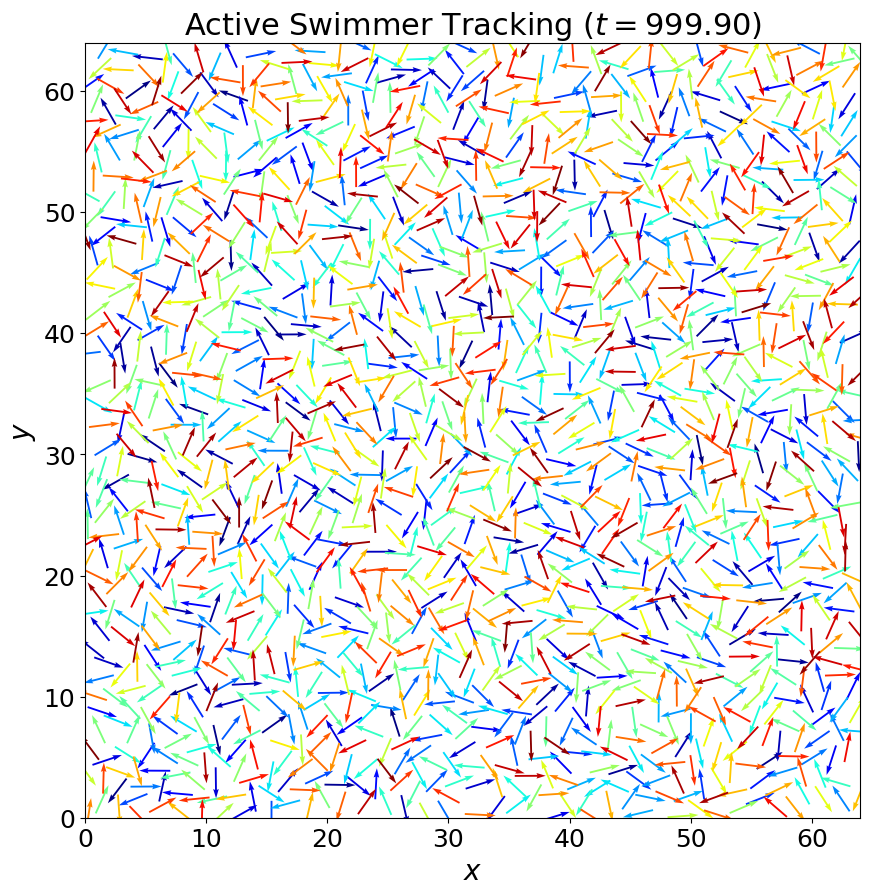

In [14]:
num_steps = positions.shape[0]

# Downsampling for smooth/faster rendering
stride = int(num_steps // 300)
plot_positions = positions[::stride]
plot_angles = angles[::stride]
plot_steps = plot_positions.shape[0]

# 2. Set up the Figure and Axis
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.set_aspect('equal')
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
title_text = ax.set_title(f"Swimmer Trajectories ($t=0.00$)")

# Initialize Swimmers using Quiver (arrows show orientation)
# Arrow directions are calculated using cos(theta) and sin(theta)
X = plot_positions[0, :, 0]
Y = plot_positions[0, :, 1]
U = np.cos(plot_angles[0, :])
V = np.sin(plot_angles[0, :])

# Color-coding arrows just to make individual tracking easier visually
colors = plt.cm.jet(np.linspace(0, 1, N))

quiver = ax.quiver(
    X, Y, U, V, 
    color=colors, 
    scale=25,          # Adjust scale to make arrows larger/smaller
    scale_units='width',
    pivot='middle'     # Rotates around the swimmer's center point
)

# 3. Animation Update Function
def update(frame):
    # Extract data for current frame
    pos = plot_positions[frame]
    ang = plot_angles[frame]
    
    # Update arrow positions
    quiver.set_offsets(pos)
    
    # Update arrow directions
    quiver.set_UVC(np.cos(ang), np.sin(ang))
    
    # Update physical time in title
    current_time = frame * stride * dt
    title_text.set_text(f"Active Swimmer Tracking ($t = {current_time:.2f}$)")
    
    return quiver, title_text

# 4. Create the Animation Class Object
print("Generating animation object...")
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=plot_steps, 
    interval=30,  # Delay between frames in ms (~33 FPS)
    blit=True
)

# 5. Export to high-quality MP4 file
output_mp4 = "swimmer_simulation_phi=4e-1_initptnoise=4e-1_Dr=1e-2.mp4"
print(f"Encoding and saving to {output_mp4}... Please wait.")

# We use the FFMpeg FileWriter with a high bitrate profile
writer = animation.FFMpegWriter(
    fps=30, 
    metadata=dict(artist='JAX-MD Stokes Simulator'), 
    bitrate=2000
)

ani.save(output_mp4, writer=writer)
print(f"Successfully saved animation to: {output_mp4}")